# 1.1.9 Example: Harvest Quotas

C:\Users\eders\AppData\Local\Temp\ipykernel_19824\763423264.py:49: RuntimeWarning: divide by zero encountered in divide
  x_sol = 0.5 + 1 / denom


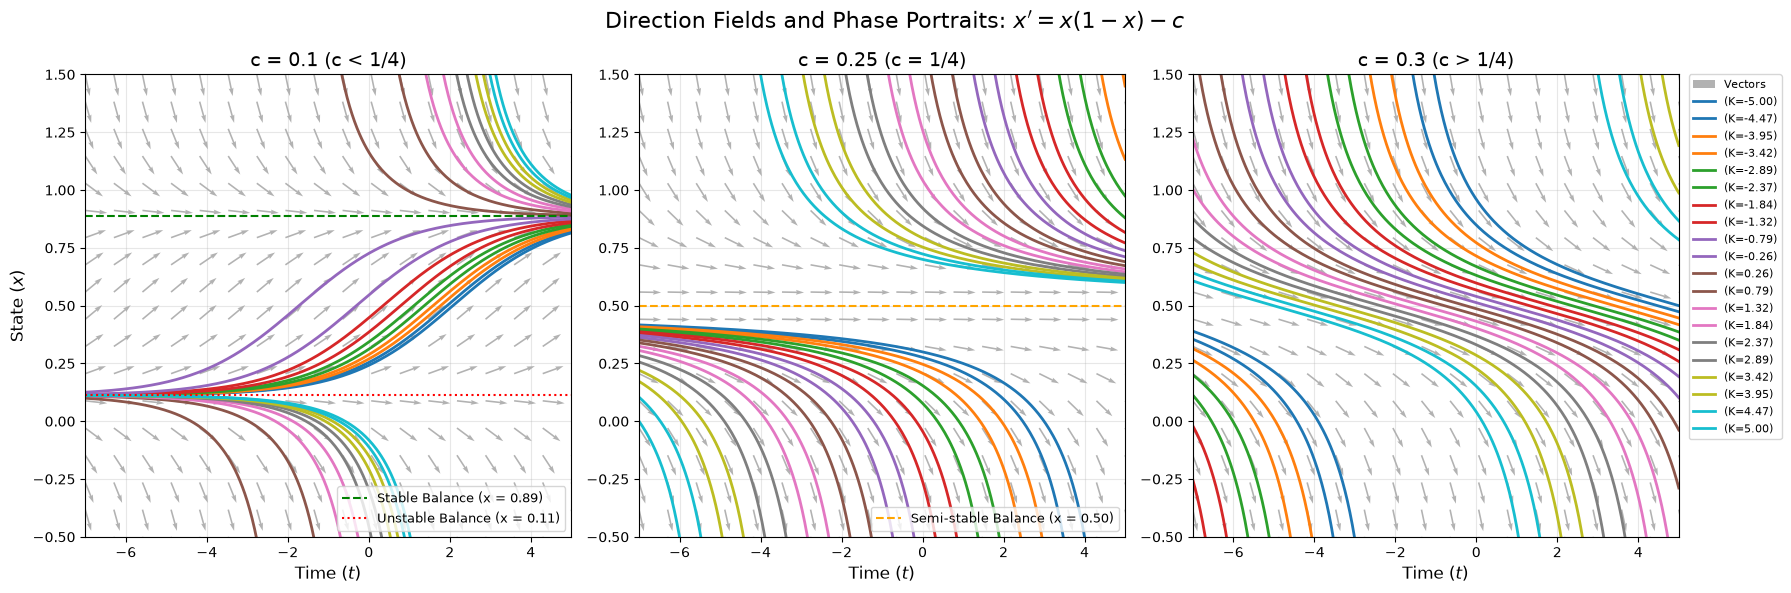

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grid configuration for vector field
t = np.linspace(-7, 5, 18)
x = np.linspace(-0.5, 1.5, 18)
T, X = np.meshgrid(t, x)

c_values = [0.1, 0.25, 0.3]
titles = ["c = 0.1 (c < 1/4)", "c = 0.25 (c = 1/4)", "c = 0.3 (c > 1/4)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

t_sol = np.linspace(-7, 5, 400)
K_values = np.linspace(-5.0, 5.0, 20)
colors = plt.cm.tab10(np.linspace(0, 1, len(K_values)))

for i, c in enumerate(c_values):
    ax = axes[i]
    
    # 2. ODE Vectors Components: x' = x(1 - x) - c
    dT = np.ones_like(T)
    dX = X * (1 - X) - c
    
    # Normalization
    magnitude = np.sqrt(dT**2 + dX**2)
    dT_norm = dT / magnitude
    dX_norm = dX / magnitude
    
    # Direction field
    ax.quiver(T, X, dT_norm, dX_norm, color='gray', alpha=0.6,
               angles='xy', scale=22, label='Vectors' if i==2 else None)
    
    # 3. Integral curves analytically
    for j, K in enumerate(K_values):
        if c < 0.25:
            A = 2 * np.sqrt(0.25 - c)
            r1 = 0.5 + A / 2
            r2 = 0.5 - A / 2
            
            denom = 1 - K * np.exp(-A * t_sol)
            x_sol = (r1 - r2 * K * np.exp(-A * t_sol)) / denom
            
            # Mask asymptotes
            x_sol[np.abs(denom) < 0.05] = np.nan
            
        elif c == 0.25:
            denom = t_sol + K
            x_sol = 0.5 + 1 / denom
            
            # Mask asymptotes
            x_sol[np.abs(denom) < 0.05] = np.nan
            
        else: # c > 0.25
            D = np.sqrt(c - 0.25)
            x_sol = 0.5 - D * np.tan(D * (t_sol + K))
            
            # Mask asymptotes
            x_sol[np.abs(np.cos(D * (t_sol + K))) < 0.05] = np.nan
            
        ax.plot(t_sol, x_sol, color=colors[j], linewidth=2, label=f'(K={K:.2f})' if i==2 else None)
    
    # Balance Lines (Where x' = 0)
    if c < 0.25:
        eq1 = 0.5 + np.sqrt(0.25 - c)
        eq2 = 0.5 - np.sqrt(0.25 - c)
        ax.axhline(eq1, color='green', linestyle='--', linewidth=1.5, label=f'Stable Balance (x = {eq1:.2f})' if i==0 else None)
        ax.axhline(eq2, color='red', linestyle=':', linewidth=1.5, label=f'Unstable Balance (x = {eq2:.2f})' if i==0 else None)
        if i==0: ax.legend(loc='lower right', fontsize=9)
    elif c == 0.25:
        eq = 0.5
        ax.axhline(eq, color='orange', linestyle='--', linewidth=1.5, label=f'Semi-stable Balance (x = {eq:.2f})' if i==1 else None)
        if i==1: ax.legend(loc='lower right', fontsize=9)
        
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("Time ($t$)", fontsize=12)
    if i == 0:
        ax.set_ylabel("State ($x$)", fontsize=12)
    ax.set_xlim(-7, 5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

# Add legend for the last subplot (K values) outside
axes[2].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)

plt.suptitle("Direction Fields and Phase Portraits: $x' = x(1-x) - c$", fontsize=16)
plt.tight_layout()
plt.show()